<a href="https://colab.research.google.com/github/mailan48692004-web/Climate-Risk-Monitoring-and-Site-Prioritisation/blob/main/notebook/notebook_2_exploring_analysis_and_risk_monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Analysis and Risk Monitoring
## Notebook Purpose

This notebook continues the project by using the processed site-month dataset prepared in Notebook 1.  
The focus here is to explore climate-related operational risk patterns, assess whether the constructed risk indicators meaningfully separate higher-risk observations, and identify which sites or groups may require closer monitoring.

The analysis is designed to support risk segmentation, business interpretation, and early-warning style decision-making rather than advanced predictive modelling.

## Load Processed Data

The processed dataset from Notebook 1 is loaded here as the analytical base for Notebook 2.  
This version already includes cleaned variables, standardised fields, and the composite indices created in the preparation stage.


## Analytical Questions

This notebook addresses four core questions:

1. Which sites, states, and site types appear to face higher disruption risk?
2. Is disruption more strongly associated with climate exposure, operational vulnerability, or business impact?
3. Do the constructed risk tiers meaningfully separate lower-risk and higher-risk observations?
4. Which sites or segments should be prioritised for monitoring and early attention?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/ESG Project/Data/climate_business_sites_processed.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Dataset check

In [ ]:
required_cols = [
    "month", "site_id", "state", "region", "site_type",
    "climate_risk_index_100", "vulnerability_score_100",
    "business_impact_score_100", "overall_risk_score_100",
    "risk_tier", "disruption_flag_next_month"
]

missing_required = [c for c in required_cols if c not in df.columns]
print("Missing required columns:", missing_required)

df["month"] = pd.to_datetime(df["month"], errors="coerce")

Missing required columns: []


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6480 entries, 0 to 6479
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   month                              6480 non-null   datetime64[ns]
 1   site_id                            6480 non-null   object        
 2   state                              6480 non-null   object        
 3   region                             6480 non-null   object        
 4   site_type                          6480 non-null   object        
 5   staff_count                        6480 non-null   int64         
 6   monthly_volume                     6480 non-null   int64         
 7   criticality_score                  6480 non-null   int64         
 8   supplier_dependency_score          6480 non-null   float64       
 9   backup_capacity                    6480 non-null   float64       
 10  emergency_plan_maturity            6

## Helper functions

In [ ]:
def add_bar_labels(ax, fmt="{:.1f}"):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(fmt.format(height),
                    (p.get_x() + p.get_width() / 2, height),
                    ha="center", va="bottom", fontsize=9, xytext=(0, 3),
                    textcoords="offset points")

def rate_table(data, group_col, target_col="disruption_flag_next_month"):
    out = (
        data.groupby(group_col, dropna=False)[target_col]
        .agg(["count", "mean", "sum"])
        .rename(columns={"count": "n_obs", "mean": "disruption_rate", "sum": "disruption_count"})
        .reset_index()
    )
    out["disruption_rate_pct"] = 100 * out["disruption_rate"]
    return out

def mean_score_table(data, group_col, score_cols):
    return (
        data.groupby(group_col)[score_cols]
        .mean()
        .round(2)
        .reset_index()
    )

score_cols = [
    "climate_risk_index_100",
    "vulnerability_score_100",
    "business_impact_score_100",
    "overall_risk_score_100"
]

## Target Inspection

The first step is to examine the distribution of the next-month disruption outcome.  
This helps assess whether disruption is relatively rare or more common, and whether risk patterns differ across location, site type, and time.

In [ ]:
eda_df = df.dropna(subset=["disruption_flag_next_month"]).copy()

print("Rows used for EDA:", eda_df.shape[0])
print("Overall disruption rate:", round(100 * eda_df["disruption_flag_next_month"].mean(), 2), "%")
target_counts = eda_df["disruption_flag_next_month"].value_counts().sort_index()
target_counts.index = ["No disruption", "Disruption"]
target_counts

Rows used for EDA: 6480
Overall disruption rate: 7.96 %


,count
No disruption,5964
Disruption,516


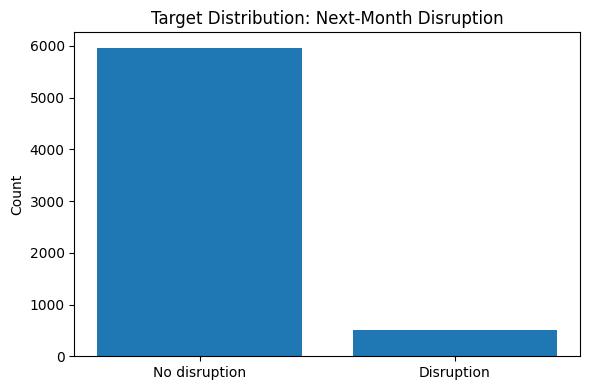

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(target_counts.index, target_counts.values)
plt.title("Target Distribution: Next-Month Disruption")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Disruption rate by state

In [ ]:
disruption_by_state = (
    eda_df.groupby("state")["disruption_flag_next_month"]
    .agg(["count", "mean", "sum"])
    .rename(columns={
        "count": "n_obs",
        "mean": "disruption_rate",
        "sum": "disruption_count"
    })
    .reset_index()
)

disruption_by_state["disruption_rate_pct"] = 100 * disruption_by_state["disruption_rate"]
disruption_by_state = disruption_by_state.sort_values("disruption_rate_pct", ascending=False)

disruption_by_state

,state,n_obs,disruption_rate,disruption_count,disruption_rate_pct
0,act,108,0.120,13,12.037
6,wa,756,0.118,89,11.772
3,sa,432,0.083,36,8.333
2,qld,1044,0.081,85,8.142
1,nsw,2232,0.077,171,7.661
5,vic,1656,0.068,112,6.763
4,tas,252,0.040,10,3.968


Disruption rates vary meaningfully across states, suggesting that climate-related operational disruption risk is not evenly distributed across the business footprint.  

ACT and WA show the highest disruption rates, while Tasmania shows the lowest. However, disruption volume is also important: although NSW does not have the highest rate, it contributes the largest number of disrupted observations due to its larger operational footprint.  

This suggests that monitoring should consider both relative disruption risk and the scale of operational exposure.

### Disruption rate by site type

In [ ]:
disruption_by_site_type = (
    eda_df.groupby("site_type")["disruption_flag_next_month"]
    .agg(["count", "mean", "sum"])
    .rename(columns={
        "count": "n_obs",
        "mean": "disruption_rate",
        "sum": "disruption_count"
    })
    .reset_index()
)

disruption_by_site_type["disruption_rate_pct"] = 100 * disruption_by_site_type["disruption_rate"]
disruption_by_site_type = disruption_by_site_type.sort_values("disruption_rate_pct", ascending=False)

disruption_by_site_type

,site_type,n_obs,disruption_rate,disruption_count,disruption_rate_pct
3,warehouse,1548,0.098,151,9.755
1,retail,2664,0.095,252,9.459
2,service centre,1044,0.071,74,7.088
0,office,1224,0.032,39,3.186


Disruption rates differ substantially across site types. Warehouses and retail sites show the highest disruption rates, while office sites have the lowest.  

This pattern is consistent with the idea that operationally intensive or customer-facing sites may be more exposed to climate-related disruption than office-based sites with more flexible operating arrangements.  

For monitoring purposes, this suggests that site type is an important segmentation variable rather than a simple descriptive field.

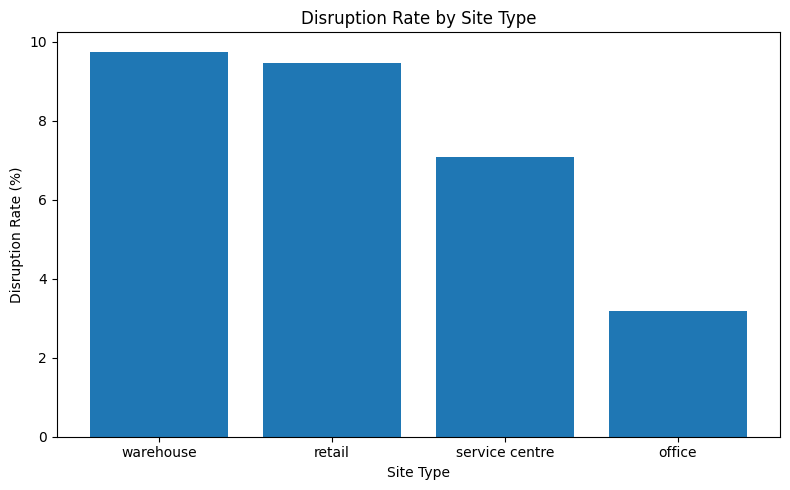

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(disruption_by_site_type["site_type"], disruption_by_site_type["disruption_rate_pct"])
plt.title("Disruption Rate by Site Type")
plt.xlabel("Site Type")
plt.ylabel("Disruption Rate (%)")
plt.xticks()
plt.tight_layout()
plt.show()

## Comparing Scores by Disruption Outcome



In [ ]:
score_cols = [
    "climate_risk_index_100",
    "vulnerability_score_100",
    "business_impact_score_100",
    "overall_risk_score_100"
]

score_by_outcome = (
    eda_df.groupby("disruption_flag_next_month")[score_cols]
    .mean()
    .round(2)
    .reset_index()
)

score_by_outcome["disruption_flag_next_month"] = score_by_outcome["disruption_flag_next_month"].map({
    0: "No disruption",
    1: "Disruption"
})

score_by_outcome

,disruption_flag_next_month,climate_risk_index_100,vulnerability_score_100,business_impact_score_100,overall_risk_score_100
0,No disruption,26.110,30.830,36.330,30.320
1,Disruption,27.660,35.020,39.550,33.210


Disrupted observations have higher average scores across all four measures.  
The strongest separation appears in vulnerability, suggesting that weaker resilience and greater operational fragility may matter more than climate exposure alone in explaining next-month disruption pressure.

## Risk Segmentation by State and Site Type

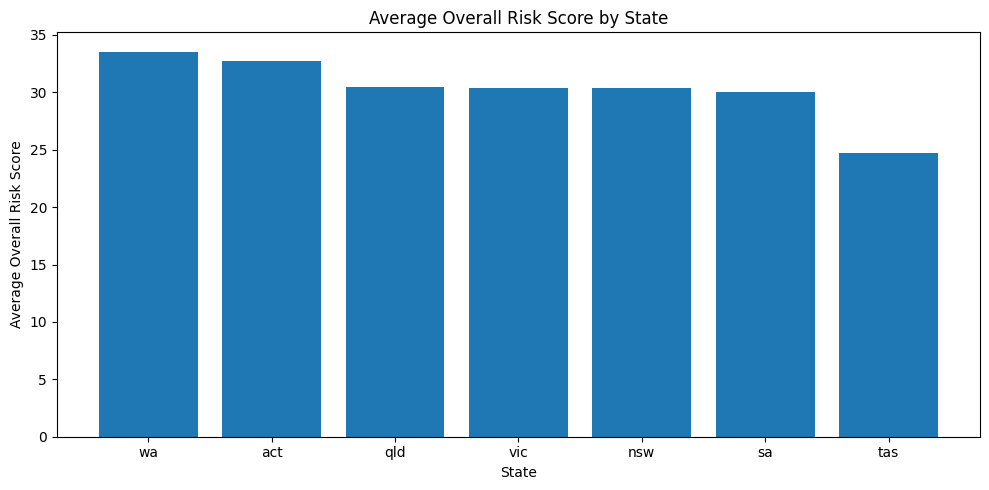

In [ ]:
scores_by_state = (
    eda_df.groupby("state")[score_cols]
    .mean()
    .round(2)
    .reset_index()
    .sort_values("overall_risk_score_100", ascending=False)
)

scores_by_state
plt.figure(figsize=(10,5))
plt.bar(scores_by_state["state"], scores_by_state["overall_risk_score_100"])
plt.title("Average Overall Risk Score by State")
plt.xlabel("State")
plt.ylabel("Average Overall Risk Score")
plt.xticks()
plt.tight_layout()
plt.show()



Average overall risk is not evenly distributed across states. WA and ACT show the highest average risk scores, while Tasmania shows the lowest.

This suggests that climate-related operational disruption pressure varies across the business footprint rather than being uniformly distributed. For monitoring purposes, this means that state-level segmentation is useful when prioritising attention and interpreting risk.

However, average score should be interpreted together with operational scale. A state may have a high average risk score but relatively fewer observations, while larger states may contribute more total disruption cases even at a lower average score.

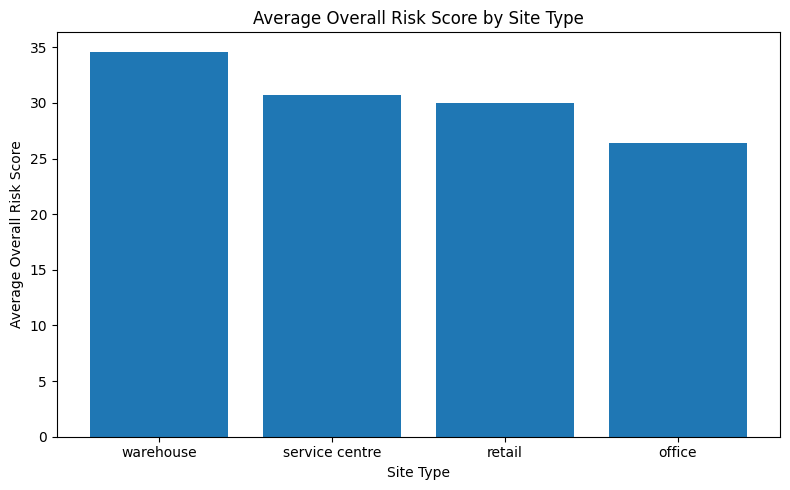

In [ ]:
scores_by_site_type = mean_score_table(df, "site_type", score_cols)
scores_by_site_type = scores_by_site_type.sort_values("overall_risk_score_100", ascending=False)
scores_by_site_type
plt.figure(figsize=(8,5))
plt.bar(scores_by_site_type["site_type"], scores_by_site_type["overall_risk_score_100"])
plt.title("Average Overall Risk Score by Site Type")
plt.xlabel("Site Type")
plt.ylabel("Average Overall Risk Score")
plt.xticks()
plt.tight_layout()
plt.show()



Average overall risk differs meaningfully across site types. Warehouses show the highest average risk scores, followed by service centres and retail sites, while office sites show the lowest.

This pattern is consistent with the idea that operationally intensive sites are more exposed to disruption pressure than office-based sites. Warehouses and service centres are likely to be more sensitive to climate-related interruption because they depend more heavily on physical operations, continuity of services, and local resilience.

This supports the use of site type as a practical segmentation variable in risk monitoring and escalation.

## Risk Tier Evaluation

The overall risk score was converted into low, medium, and high risk tiers to support simpler monitoring and communication.
This section checks whether those tiers align with meaningful differences in next-month disruption rates.

In [ ]:
tier_counts = eda_df["risk_tier"].value_counts(dropna=False).reset_index()
tier_counts.columns = ["risk_tier", "count"]
tier_counts

,risk_tier,count
0,low,4617
1,medium,1863


In [ ]:
disruption_by_tier = (
    eda_df.groupby("risk_tier")["disruption_flag_next_month"]
    .agg(["count", "mean", "sum"])
    .rename(columns={
        "count": "n_obs",
        "mean": "disruption_rate",
        "sum": "disruption_count"
    })
    .reset_index()
)

disruption_by_tier["disruption_rate_pct"] = 100 * disruption_by_tier["disruption_rate"]
disruption_by_tier

,risk_tier,n_obs,disruption_rate,disruption_count,disruption_rate_pct
0,low,4617,0.060,279,6.043
1,medium,1863,0.127,237,12.721


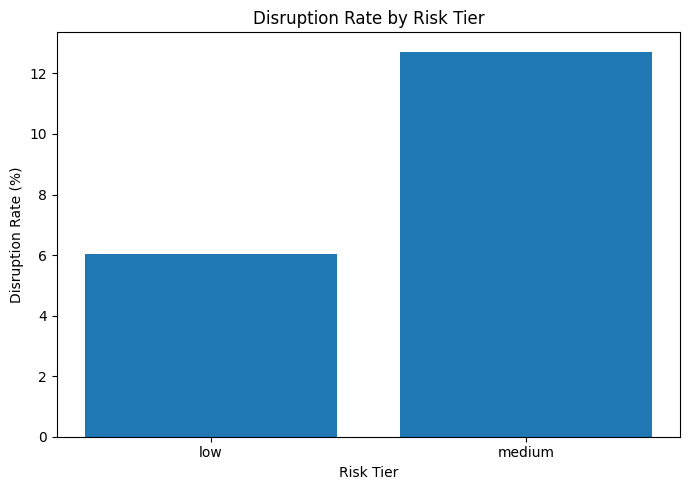

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(disruption_by_tier["risk_tier"].astype(str), disruption_by_tier["disruption_rate_pct"])
plt.title("Disruption Rate by Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Disruption Rate (%)")
plt.tight_layout()
plt.show()

## Key Risk Drivers

To better understand what sits behind higher-risk observations, selected hazard, vulnerability, and resilience variables are compared across groups.
The goal is not advanced modelling, but clearer business interpretation of what appears to sit behind disruption pressure.

In [ ]:
driver_cols = [
    "heatwave_days",
    "flood_warning_days",
    "bushfire_danger_index",
    "storm_outage_hours",
    "supplier_dependency_score",
    "backup_capacity",
    "emergency_plan_maturity",
    "historical_disruptions_3m",
    "criticality_score",
    "volume_per_staff"
]

drivers_by_outcome = (
    eda_df.groupby("disruption_flag_next_month")[driver_cols]
    .mean()
    .round(2)
    .reset_index()
)

drivers_by_outcome["disruption_flag_next_month"] = drivers_by_outcome["disruption_flag_next_month"].map({
    0: "No disruption",
    1: "Disruption"
})

drivers_by_outcome

,disruption_flag_next_month,heatwave_days,flood_warning_days,bushfire_danger_index,storm_outage_hours,supplier_dependency_score,backup_capacity,emergency_plan_maturity,historical_disruptions_3m,criticality_score,volume_per_staff
0,No disruption,3.080,0.600,83.000,5.490,52.380,0.480,3.670,0.200,3.180,"1,990.870"
1,Disruption,3.840,0.680,85.650,6.110,56.680,0.450,3.650,0.450,3.370,"2,349.560"


In [ ]:
drivers_by_tier = (
    eda_df.groupby("risk_tier")[driver_cols]
    .mean()
    .round(2)
    .reset_index()
)

drivers_by_tier

,risk_tier,heatwave_days,flood_warning_days,bushfire_danger_index,storm_outage_hours,supplier_dependency_score,backup_capacity,emergency_plan_maturity,historical_disruptions_3m,criticality_score,volume_per_staff
0,low,2.730,0.560,81.520,5.430,48.440,0.480,3.600,0.100,2.900,"1,884.370"
1,medium,4.160,0.730,87.400,5.820,63.330,0.500,3.850,0.520,3.920,"2,354.160"




The driver patterns are consistent across both outcome and tier comparisons. Disrupted observations and medium-risk observations generally show higher hazard exposure, higher supplier dependency, higher recent disruption history, higher criticality, and higher workload intensity than their counterparts.

This suggests that the framework is capturing a meaningful combination of climate pressure and operational vulnerability, which supports its use for monitoring and prioritisation.

/tmp/ipykernel_337/3439253060.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["No disruption", "Disruption"])


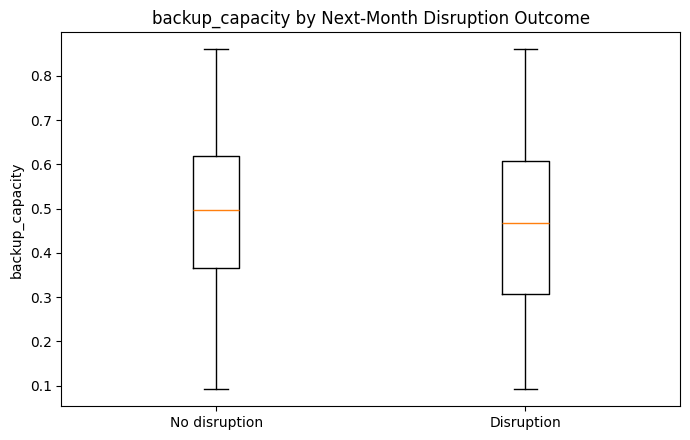

/tmp/ipykernel_337/3439253060.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["No disruption", "Disruption"])


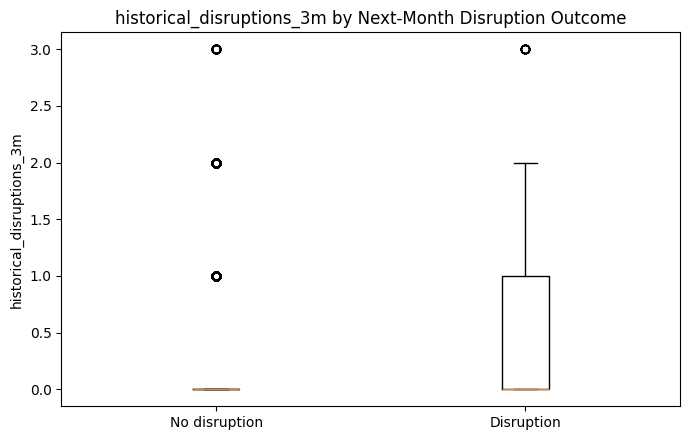

/tmp/ipykernel_337/3439253060.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["No disruption", "Disruption"])


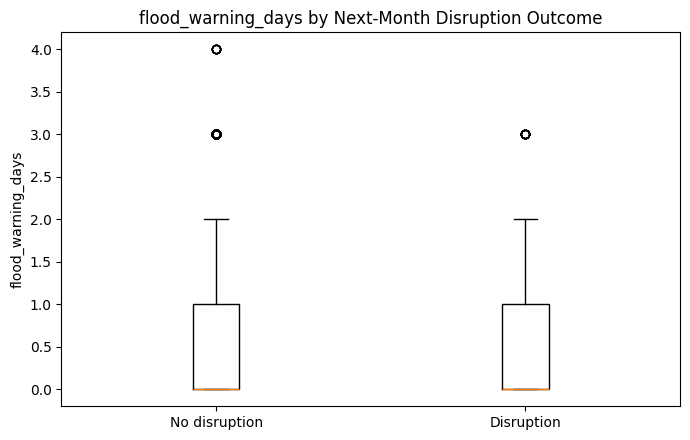

In [ ]:
focus_vars = ["backup_capacity", "historical_disruptions_3m", "flood_warning_days"]

for col in focus_vars:
    plt.figure(figsize=(7,4.5))
    plot_data = [
        eda_df.loc[eda_df["disruption_flag_next_month"] == 0, col].dropna(),
        eda_df.loc[eda_df["disruption_flag_next_month"] == 1, col].dropna()
    ]
    plt.boxplot(plot_data, labels=["No disruption", "Disruption"])
    plt.title(f"{col} by Next-Month Disruption Outcome")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Backup capacity is slightly lower for disrupted observations, but the distribution overlap remains substantial. This suggests that lower backup capacity may contribute to disruption pressure, although it does not appear to be a strong standalone separator.

Recent disruption history shows much clearer separation across outcome groups than several other variables. Disrupted observations are more likely to have higher recent disruption counts, suggesting that recent operational instability is an important signal for monitoring future disruption pressure.

Recent disruption history shows much clearer separation across outcome groups than several other variables. Disrupted observations are more likely to have higher recent disruption counts, suggesting that recent operational instability is an important signal for monitoring future disruption pressure.

## High-Risk Site Shortlist

To move from analysis to decision support, the highest-risk site-month observations are identified for closer review.

In [ ]:
latest_month = eda_df["month"].max()
latest_df = eda_df[eda_df["month"] == latest_month].copy()

print("Latest month:", latest_month)
print("Rows in latest month:", latest_df.shape[0])

Latest month: 2025-12-01 00:00:00
Rows in latest month: 180


In [ ]:
shortlist_cols = [
    "month", "site_id", "state", "region", "site_type",
    "climate_risk_index_100", "vulnerability_score_100",
    "business_impact_score_100", "overall_risk_score_100",
    "risk_tier", "disruption_flag_next_month"
]

top_high_risk_sites = (
    latest_df[shortlist_cols]
    .sort_values("overall_risk_score_100", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_high_risk_sites

,month,site_id,state,region,site_type,climate_risk_index_100,vulnerability_score_100,business_impact_score_100,overall_risk_score_100,risk_tier,disruption_flag_next_month
0,2025-12-01,s0026,wa,south west,warehouse,31.050,63.450,58.194,49.176,medium,0
1,2025-12-01,s0074,wa,kimberley,retail,33.700,65.295,43.782,47.279,medium,0
2,2025-12-01,s0013,wa,south west,service centre,33.267,52.910,60.635,46.984,medium,1
3,2025-12-01,s0036,wa,perth,warehouse,33.075,46.818,66.883,46.337,medium,0
4,2025-12-01,s0132,nsw,riverina,warehouse,33.042,32.030,81.190,44.725,medium,0
5,2025-12-01,s0133,nsw,riverina,warehouse,32.083,43.322,65.185,44.292,medium,1
6,2025-12-01,s0010,qld,greater brisbane,warehouse,27.883,52.128,57.928,43.880,medium,0
7,2025-12-01,s0068,wa,south west,service centre,34.742,45.417,54.540,43.427,medium,0
8,2025-12-01,s0121,wa,goldfields,warehouse,33.275,35.080,71.352,43.426,medium,0
9,2025-12-01,s0118,nsw,hunter,warehouse,31.508,30.170,79.458,43.027,medium,0


The latest-month shortlist highlights a concentration of higher-risk observations in WA and among warehouse-type sites. Although not all shortlisted observations experience next-month disruption, the list still provides a practical monitoring output by identifying where risk conditions are elevated enough to justify closer attention.

This is consistent with the purpose of a watchlist: to support prioritisation rather than to guarantee event occurrence.

## Implications for Monitoring and Dashboard Design

In [ ]:
kpi_summary = pd.DataFrame({
    "kpi": [
        "Average overall risk score",
        "% high-risk observations",
        "Overall disruption rate (%)",
        "Latest-month high-risk sites",
        "Latest-month average climate risk",
        "Latest-month average vulnerability"
    ],
    "value": [
        eda_df["overall_risk_score_100"].mean(),
        100 * (eda_df["risk_tier"].astype(str) == "high").mean(),
        100 * eda_df["disruption_flag_next_month"].mean(),
        (latest_df["risk_tier"].astype(str) == "high").sum(),
        latest_df["climate_risk_index_100"].mean(),
        latest_df["vulnerability_score_100"].mean()
    ]
})

kpi_summary

,kpi,value
0,Average overall risk score,30.546
1,% high-risk observations,0.000
2,Overall disruption rate (%),7.963
3,Latest-month high-risk sites,0.000
4,Latest-month average climate risk,31.795
5,Latest-month average vulnerability,31.142


#Note
Notebook 2 suggests that the monitoring framework is useful for relative prioritisation, but the current score thresholds may be too conservative for practical watchlist design because they do not yet produce a high-risk group.

The next stage of the project should therefore focus on:
- refining the alert or risk-tier thresholds,
- highlighting medium- and higher-risk site-month observations,
- surfacing the most relevant drivers behind elevated risk,
- and translating these findings into a dashboard and early-warning structure for business users.

## Answers to Analytical Questions

**1. Which sites, states, and site types appear to face higher disruption risk?**  
Higher disruption risk appears to be concentrated in certain states, especially WA and ACT on average score measures, while warehouses and service centres show higher risk than office sites. In the latest-month shortlist, many of the highest-risk observations are concentrated in WA and are often warehouse-type sites.

**2. Is disruption more strongly associated with climate exposure, operational vulnerability, or business impact?**  
Disruption appears to be associated with all three dimensions, but the clearest separation is seen in operational vulnerability and business impact rather than climate exposure alone. Recent disruption history, supplier dependency, criticality, and workload intensity appear especially relevant.

**3. Do the constructed risk tiers meaningfully separate lower-risk and higher-risk observations?**  
Yes. The medium-risk tier shows a substantially higher disruption rate than the low-risk tier, indicating that the current tiering framework provides meaningful relative separation for monitoring purposes.

**4. Which sites or segments should be prioritised for monitoring and early attention?**  
Sites in higher-risk states, especially those in warehouse and service-centre categories, should be prioritised for monitoring. Observations with higher overall risk scores, stronger recent disruption history, higher supplier dependency, and greater workload intensity are particularly suitable for watchlist-style attention.

## Notebook 2 Summary

This notebook explored how climate exposure, vulnerability, resilience, and business impact relate to next-month disruption risk.

The analysis shows that risk is unevenly distributed across states and site types, and that the constructed scores provide meaningful relative separation across observations. Medium-risk observations have materially higher disruption rates than low-risk observations, while driver comparisons suggest that recent disruption history, supplier dependency, workload intensity, and lower resilience are especially relevant.

The next step is to convert these findings into a more practical dashboard and alert framework, including threshold refinement for watchlist and escalation purposes.